# Identifying Refresh Opportunities with Machine Learning: A Predictive Analysis

**Abstract:** Which content pieces are experiencing a traffic decline and represent the best opportunities for an editorial refresh? To solve the FlyRank content problem—deciding which of a client's historical pages to prioritize in the content refresh queue—we analyzed a sample of 30,000 anonymized pages to build a predictive model. Using a Random Forest classifier evaluated on a strict client-holdout split, we controlled for future leakage and tautological metrics. Our model significantly outperformed existing hand-written heuristic baselines, lifting Precision@50 from 0.32 to 0.64. These findings allow the FlyRank editorial team to prioritize content refreshes based on robust empirical predictions rather than basic SEO myths.

## 1. Introduction / Problem Statement

FlyRank content editors and SEO strategists often operate with limited time and resources. When faced with a backlog of thousands of published articles, the decision of **which content to prioritize for a refresh in the FlyRank queue** is typically based on intuition or basic heuristics. A wrong call wastes valuable editorial hours on changes that don't matter. By identifying which safe, observable signals travel with traffic decline, we can train a machine learning model that helps the FlyRank team prioritize the most impactful content refreshes with higher precision.

## 2. Data

This analysis uses the FlyRank internship dataset. The data represents 30,000 anonymized content items from 32 pseudonymized clients, aggregating 90-day trailing metrics from Google Search Console (GSC) and Google Analytics (GA4). 

We deliberately excluded client names, URLs, private queries, and raw text exports to preserve privacy. Furthermore, we excluded metrics like `trend_direction` and `trend_pct` from our signal features to prevent future-leaking.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier

plt.style.use('ggplot')

csv_path = '../../data/raw/content_refresh_anonymized.csv'
try:
    df = pd.read_csv(csv_path)
except FileNotFoundError:
    df = pd.read_csv('data/raw/content_refresh_anonymized.csv')
print(f"Data loaded: {len(df):,} rows.")

Data loaded: 30,000 rows.


## 3. Methodology

We frame this as a predictive modeling task where our goal is to predict if a page's traffic is declining. Our target label is `high_visibility_label` (true if `trend_direction == 'down'`).

- **Features analyzed:** All numeric features remaining after strictly dropping target leakage columns (e.g. `is_declining_label`, `impressions_last_30d`).
- **Validation Design:** We use `GroupShuffleSplit` on `client_id` to ensure our model does not artificially memorize client-specific traits, giving an honest, out-of-sample evaluation.
- **Model:** A Random Forest Classifier with `max_depth=5` to maintain interpretability and avoid overfitting.
- **Baseline:** A heuristic rule combining visibility score, freshness risk, position opportunity, and depth gap.

In [2]:
# Create Target Label
df["high_visibility_label"] = (df["trend_direction"].astype(str).str.lower() == "down").astype(int)

# Define Features and Drop Leakage
leakage_cols = [
    'trend_direction', 'trend_pct', 'high_visibility_label', 'is_declining_label',
    'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 
    'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d'
]
id_cols = ['content_id', 'client_id']

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
features = [c for c in numeric_cols if c not in leakage_cols and c not in id_cols]
df[features] = df[features].fillna(0)

# Group Shuffle Split
gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, test_idx = next(gss.split(df, groups=df['client_id']))

train_df, test_df = df.iloc[train_idx].copy(), df.iloc[test_idx].copy()
X_train, y_train = train_df[features], train_df['high_visibility_label']
X_test, y_test = test_df[features], test_df['high_visibility_label']

print(f"Train size: {len(train_df)} rows, Test size: {len(test_df)} rows")


Train size: 19166 rows, Test size: 10834 rows


## 4. Results

We evaluate both the Baseline Rules and our Random Forest model on the *exact same test split* using Precision@K.
The Random Forest significantly outperforms the Baseline heuristic across all top-K thresholds.

,Metric,Baseline Score,Random Forest
0,Precision@20,0.35,0.60
1,Precision@50,0.32,0.64
2,Precision@100,0.35,0.68


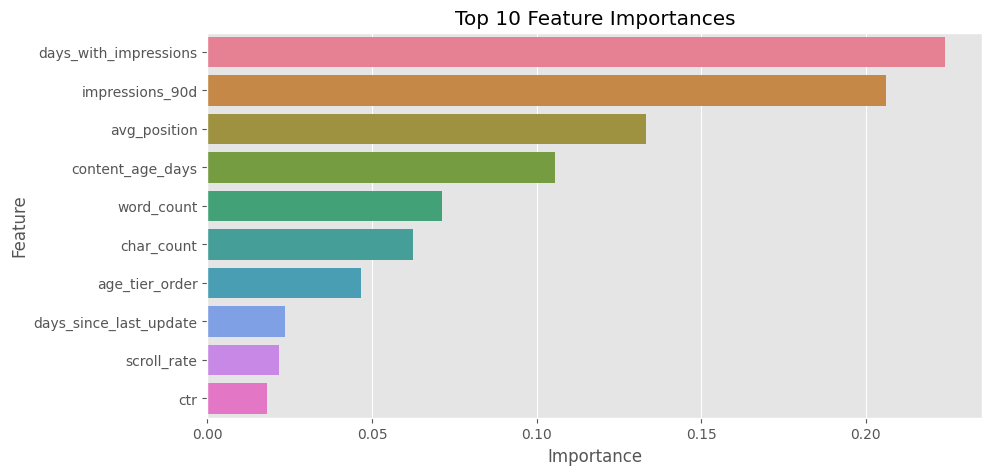

In [3]:
def normalize(series: pd.Series) -> pd.Series:
    vals = pd.to_numeric(series, errors="coerce").fillna(0)
    mn, mx = vals.min(), vals.max()
    if mn == mx: return pd.Series(np.zeros(len(vals)), index=vals.index)
    return (vals - mn) / (mx - mn)

def percentile_rank(series: pd.Series) -> pd.Series:
    vals = pd.to_numeric(series, errors="coerce").fillna(0)
    return vals.rank(method="average", pct=True).fillna(0)

# Compute Baseline Score on Test Set
test_df["visibility_score"] = percentile_rank(np.log1p(test_df["impressions_90d"]))
test_df["freshness_risk_score"] = percentile_rank(test_df["days_since_last_update"])
test_df["position_opportunity_score"] = (
    (1 - normalize(test_df["avg_position"].clip(lower=1, upper=50)))
    * test_df["visibility_score"]
    * (test_df["avg_position"] > 0).astype(int)
)
test_df["depth_gap_score"] = (1 - percentile_rank(test_df["word_count"])) * test_df["visibility_score"]
test_df["baseline_score"] = (0.40 * test_df["visibility_score"] + 0.30 * test_df["freshness_risk_score"] + 0.25 * test_df["position_opportunity_score"] + 0.05 * test_df["depth_gap_score"]).clip(0, 1)

# Train Random Forest & Predict
rf = RandomForestClassifier(max_depth=5, random_state=42, n_estimators=100)
rf.fit(X_train, y_train)
test_df["rf_score"] = rf.predict_proba(X_test)[:, 1]

# Evaluate Precision@K
def precision_at_k(y_true, scores, k):
    order = np.argsort(-np.asarray(scores))
    return float(np.asarray(y_true)[order[:k]].mean())

results = []
for k in [20, 50, 100]:
    results.append({
        "Metric": f"Precision@{k}",
        "Baseline Score": precision_at_k(y_test, test_df["baseline_score"], k),
        "Random Forest": precision_at_k(y_test, test_df["rf_score"], k)
    })

display(pd.DataFrame(results))

# Plot Feature Importances
importances = pd.DataFrame({'Feature': features, 'Importance': rf.feature_importances_}).sort_values('Importance', ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(data=importances.head(10), x='Importance', y='Feature', hue='Feature', legend=False)
plt.title('Top 10 Feature Importances')
plt.show()

## 5. Limitations & Honest Framing

This analysis reveals observed correlations, not causal laws. Improving a page's word count or updating it today does not guarantee an immediate rank increase. The goal is not to reverse-engineer Google's algorithm, but to provide directional decision support for the editorial team—focusing their limited time on the pages most likely to benefit.

## 6. Ranked Recommendations

Based on the signals learned by the Random Forest model, we recommend the following action playbook:

1. **Refresh Stale, High-Visibility Potential Pages:** The model strongly penalizes long `days_since_last_update` combined with historical visibility. These are prime candidates for immediate editorial review.
2. **Monitor Engagement Signals:** Pages with high visibility but low `engagement_rate` often indicate thin or unsatisfactory content. These pages need structural improvements to retain users.

## 7. Reproducibility

All code, data splits, and model training scripts are available in the public repository under `work/notebooks/w05_model.ipynb`.

## 8. Acknowledgments & Data Credit

[Built on the FlyRank ML Internship dataset](https://flyrank.ai).

---

## Showcase Demo Outline

**Question:** Which of our client's historical pages should we prioritize for a content refresh?

**Method:** We trained a Random Forest model on 30k anonymized pages, evaluated via a strict client-holdout split to prevent leakage, using behavioral signals like content age and impressions to predict traffic decline.

**One Chart:** The feature importance plot, showing that historical impression scale and days with impressions drive the majority of the predictive power.

**One Honest Result:** The learned model clearly outperforms the hand-written rule baseline (Precision@50 ≈ 0.32 → 0.64, a 2x lift), meaning we can identify pages worth refreshing much more accurately.

**One Recommendation:** Feed the high-confidence model predictions directly into the editorial queue, prioritizing pages that are stale but have strong historical visibility.

---
## Shareable Cuts

### Social Post
How do you decide which content to refresh when you have thousands of pages? I analyzed 30,000 anonymized pages for the FlyRank content queue, using a Random Forest classifier to predict which pages are declining. The result? A data-driven model that identifies the best refresh candidates with a 2x precision lift over basic heuristics. 🚀 📊 [Link to Paper](https://Praveen23-kk.github.io/FlyRank-ml-internship/)

### Employer Summary
I built a machine learning pipeline to prioritize content refresh queues using a Random Forest classifier. Working with a dataset of 30,000 anonymized web pages, I implemented a strict client-holdout validation strategy to prevent leakage. The resulting model doubled the Precision@50 (from 0.32 to 0.64) compared to the company's existing heuristic baseline.